## Hand Gesture Recognition Model

### Using MediaPipe Tasks and CNN

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import tensorflow as tf
from tensorflow import keras # type: ignore
from tensorflow.keras import layers, models # type: ignore

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

import cv2
import mediapipe as mp
import os

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

## Section 1: Dataset Overview and Exploration

- Features: 63 normalized hand landmark coordinates (21 joints x 3 dimensions)
- Labels: 6 gesture classes (fist, index_finger, OK, open_palm, peace, thumb_up)

In [2]:
df = pd.read_csv('merged_dataset/merged_dataset_cleaned.csv')

X = df.iloc[:, :63].values     # All rows, first 63 columns (features)
y = df.iloc[:, 63].values      # All rows, last (63) column (labels)

print("Dataset Shape:", df.shape)

# Count samples per gesture class
print("\nSamples per Gesture Class:")
class_distribution = pd.Series(y).value_counts().sort_index()
print(class_distribution)

Dataset Shape: (9093, 64)

Samples per Gesture Class:
fist            1299
index_finger    1299
ok              1299
open_palm       1299
peace           1299
thumb_up        1299
unrecognized    1299
Name: count, dtype: int64


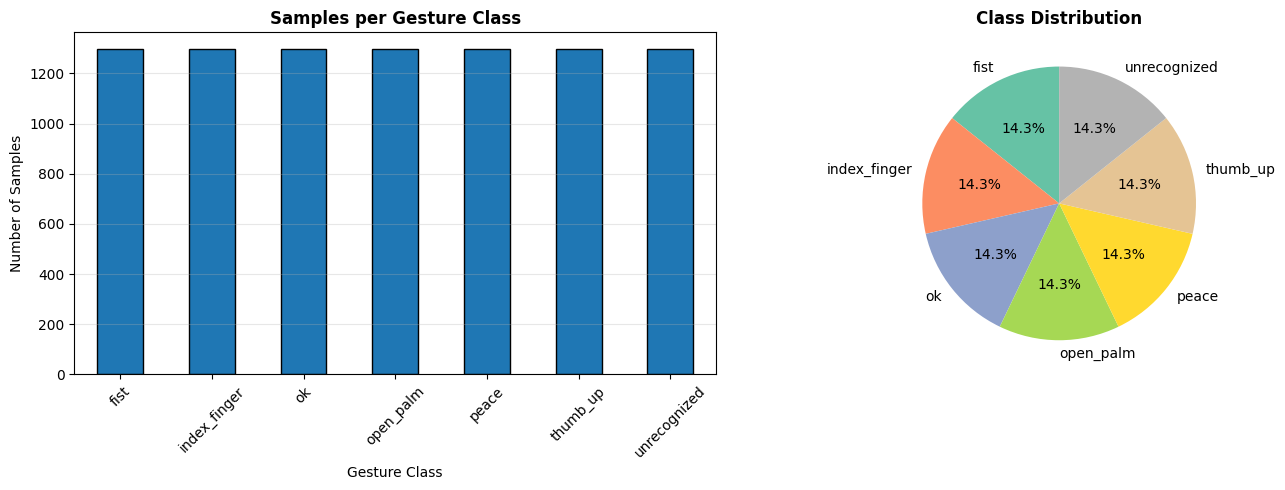

In [4]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_distribution.plot(kind='bar', ax=axes[0], edgecolor='black')
axes[0].set_title("Samples per Gesture Class", fontweight='bold')
axes[0].set_xlabel("Gesture Class")
axes[0].set_ylabel("Number of Samples")
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

color = plt.cm.Set2(np.linspace(0, 1, len(class_distribution))) # color map
axes[1].pie(class_distribution.values, labels=class_distribution.index, autopct='%1.1f%%', 
            colors=color, startangle=90)
axes[1].set_title("Class Distribution", fontweight='bold')

plt.tight_layout()
plt.show()

## Section 2: Prepare the Dataset

- Encode gesture labels to numeric values
- Normalize landmark coordinates
- Split data (70-15-15)

In [3]:
print("Features shape:", X.shape)
print("Labels shape", y.shape)
print("Unique Gestures", np.unique(y))  # np.unique returns values sorted in ascending order

# Encode target labels to numeric values
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("\nLabel Encoding:")
for i, gesture in enumerate(label_encoder.classes_):    # fit to the classes during fit(y)
    print(f"{gesture} -> {i}")

# Store them to a dict for gesture to label and vice versa, just for readability
gesture_to_label = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
label_to_gesture = {v: k for k, v in gesture_to_label.items()}

# Normalize features
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

print("\nFeature Normalization:")
print(f"Mean: {X_normalized.mean():.2f}")
print(f"Std Dev: {X_normalized.std():.2f}")     # each feature has a std dev ~ 0.98

# Split data into train (70%), validation (15%), test (15%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_normalized, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
    # stratify makes all split have balanced classes (same proportions)
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("===================")
print("Dataset Split:")
print("===================")
print("Training set:", len(X_train))
print("Validation set:", len(X_val))
print("Test set:", len(X_test))


Features shape: (9093, 63)
Labels shape (9093,)
Unique Gestures ['fist' 'index_finger' 'ok' 'open_palm' 'peace' 'thumb_up' 'unrecognized']

Label Encoding:
fist -> 0
index_finger -> 1
ok -> 2
open_palm -> 3
peace -> 4
thumb_up -> 5
unrecognized -> 6

Feature Normalization:
Mean: -0.00
Std Dev: 0.98
Dataset Split:
Training set: 6365
Validation set: 1364
Test set: 1364


## Section 3: Extract Hand Landmarks with MediaPipe Tasks

- We use the `hand_landmarker.task`
    - It is a pre-trained neural network model that MediaPipe provides
    - Without it: `mp.tasks.vision.HandLandmarker` has no brain to detect hands
- It is basically a file containing trained weights from a deep learning model that's already been optimized to detect hands

In [6]:
import urllib.request

MODEL_PATH = "hand_landmarker.task"

if not os.path.exists(MODEL_PATH):
    print("Hand landmarker model not found locally")
    print("Downloading hand_landmarker.task from MediaPipe resources...")
    
    model_url = "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"
    
    try:
        urllib.request.urlretrieve(model_url, MODEL_PATH)
        print(f"Model downloaded and saved to: {MODEL_PATH}")
    except Exception as e:
        print(f"Could not download model automatically. Please download from:")
        print(f"{model_url}")
        print(f"And save to: {MODEL_PATH}")
else:
    print(f"Model Found at: {MODEL_PATH}")

Model Found at: hand_landmarker.task


- **BaseOptions**: Base config class for MediaPipe tasks (Used to specify the model file; in this case, hand_landmarker.task)
- **HandLandmarker**: **main** class that detects hand landmarks. It analyzes images and finds the 21 hand joints
- **HandLandmarkerOptions**: Config/settings for **HandLandmarker**
- **VisionRunningMode**: Enum specifying how to run detection (tells mp, I'm giving you image, or video, or live stream)

In [7]:
# Initialize HandLandmarker via tasks (solutions is deprecated)
# For some reasons, we can't do sth like:
    # from mediapipe.tasks import vision...

BaseOptions = mp.tasks.BaseOptions
HandLandmarker = mp.tasks.vision.HandLandmarker
HandLandmarkerOptions = mp.tasks.vision.HandLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

options = HandLandmarkerOptions(
    base_options = BaseOptions(model_asset_path=MODEL_PATH),
    running_mode = VisionRunningMode.IMAGE  # Use IMAGE mode 
)

hand_landmarker = HandLandmarker.create_from_options(options)

print("HandLandmarker initialized successfully!")


HandLandmarker initialized successfully!



Visualizing sample landmarks from each gesture class:


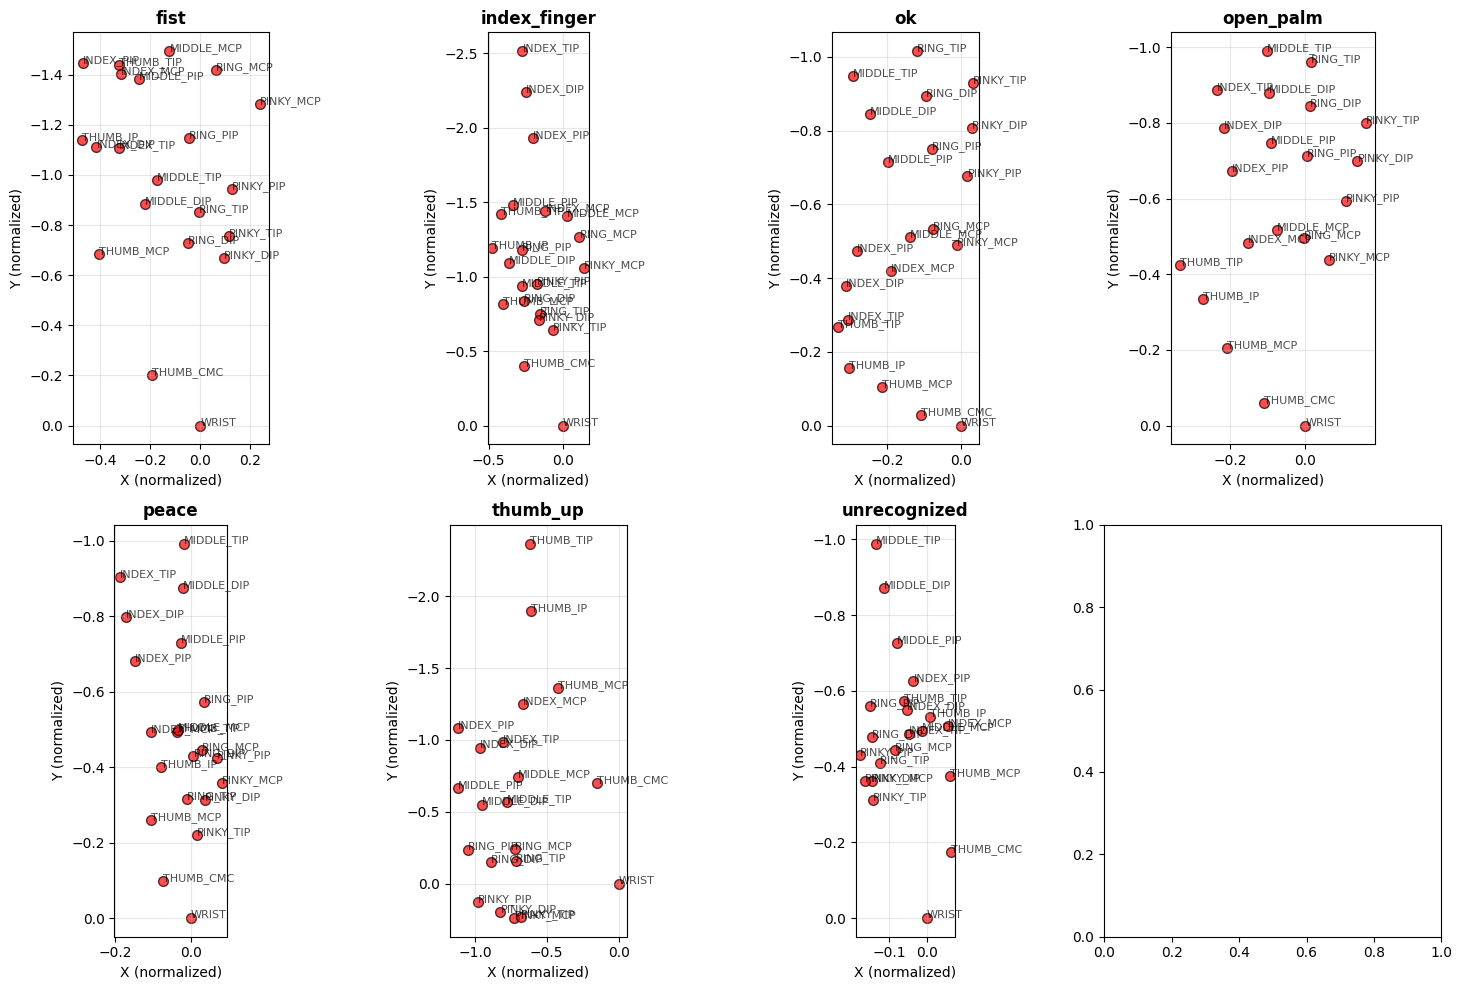

In [12]:
# Visualize landmarks for all gesture classes in a 2x3 grid
print("\nVisualizing sample landmarks from each gesture class:")
print("="*60)

# Create a 2x3 grid of subplots
fig, axes = plt.subplots(2, 4, figsize=(15, 10))
axes = axes.flatten()  # Flatten to make indexing easier

# Define joint names once
joint_names = [
    'WRIST', 'THUMB_CMC', 'THUMB_MCP', 'THUMB_IP', 'THUMB_TIP',
    'INDEX_MCP', 'INDEX_PIP', 'INDEX_DIP', 'INDEX_TIP',
    'MIDDLE_MCP', 'MIDDLE_PIP', 'MIDDLE_DIP', 'MIDDLE_TIP',
    'RING_MCP', 'RING_PIP', 'RING_DIP', 'RING_TIP',
    'PINKY_MCP', 'PINKY_PIP', 'PINKY_DIP', 'PINKY_TIP'
]

# First pass: find min/max X and Y across all gestures
min_x, max_x = float('inf'), float('-inf')
min_y, max_y = float('inf'), float('-inf')

for gesture_idx in range(len(label_encoder.classes_)):
    gesture_name = label_encoder.classes_[gesture_idx]
    mask = y_encoded == gesture_idx
    sample_idx = np.where(mask)[0][0]  # Get first sample of this gesture
    
    # Get landmarks and reshape
    landmarks = X[sample_idx].reshape(21, 3)
    
    # Plot on the corresponding subplot
    ax = axes[gesture_idx]
    ax.scatter(landmarks[:, 0], landmarks[:, 1], s=50, c='red', alpha=0.7, edgecolors='black')
    
    # Add joint labels
    for i, (x, y, z) in enumerate(landmarks):
        ax.annotate(joint_names[i], (x, y), fontsize=8, alpha=0.7)
    
    ax.set_title(f'{gesture_name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('X (normalized)')
    ax.set_ylabel('Y (normalized)')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    ax.invert_yaxis()  # Invert the Y-axis
    # MediaPipe coordinates Y=0 = top of image, Y=1 = bottom (image-based)
    # Matplotlib do it mathematically (Y=1 = top, y=0 = bottom)

plt.tight_layout()
plt.show()

Model 1: Random Forest

In [21]:
print("="*70)
print("Training Model 1: Random Forest")
print("="*70)

# Build and train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

print("\nTraining Random Forest...")
start_time = time.time()
rf_model.fit(X_train, y_train)
rf_training_time = time.time() - start_time

print(f"✓ Random Forest trained in {rf_training_time:.2f}s")

# Evaluate on test set
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
print(f"✓ Test Accuracy: {rf_acc*100:.2f}%")

print("="*70)

Training Model 1: Random Forest

Training Random Forest...
✓ Random Forest trained in 0.74s
✓ Test Accuracy: 99.12%


Model 2: XGBoost

In [22]:
print("="*70)
print("Training Model 2: XGBoost")
print("="*70)

# Build XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=7,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

print("\nTraining XGBoost...")
start_time = time.time()
xgb_model.fit(X_train, y_train)
xgb_training_time = time.time() - start_time

print(f"✓ XGBoost trained in {xgb_training_time:.2f}s")

# Evaluate on test set
xgb_pred = xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_pred)
print(f"✓ Test Accuracy: {xgb_acc*100:.2f}%")

print("="*70)

Training Model 2: XGBoost

Training XGBoost...
✓ XGBoost trained in 2.16s
✓ Test Accuracy: 98.75%


Model 3: Simple DNN with 1 hidden layer

In [ ]:
print("="*70)
print("Training Model 3: Simple DNN (1 hidden layer)")
print("="*70)

# Build Deeper DNN
simple_dnn = models.Sequential([
    # Input layer (63 features)
    layers.Input(shape=(63,)),

    # Hidden layers with Dropout 
    layers.Dense(128, activation='relu'),    # 1st layer normally starts bigger than input
    layers.Dropout(0.3),

    # Output layer
    layers.Dense(7, activation='softmax')
])

simple_dnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train Deeper DNN
print("\nTraining Simple DNN...")
start_time = time.time()
simple_history = simple_dnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=16,  # standard power of 2 (n^2) batch size
    verbose=0,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        )
    ]
)
simple_training_time = time.time() - start_time
print(f"✓ Simple DNN trained in {simple_training_time:.2f}s")

# Evaluate on test set
simple_pred = np.argmax(simple_dnn.predict(X_test, verbose=0), axis=1)
simple_acc = accuracy_score(y_test, simple_pred)
print(f"✓ Test Accuracy: {simple_acc*100:.2f}%")

print("="*70)

Training Model 3: Simple DNN (1 hidden layer)

Training Simple DNN...
✓ Simple DNN trained in 24.52s
✓ Test Accuracy: 99.63%


In [27]:
simple_dnn.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,287 (106.59 KB)

 Trainable params: 9,095 (35.53 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 18,192 (71.07 KB)

In [ ]:
print("="*70)
print("Training Model 4: Deeper DNN (3 hidden layers)")
print("="*70)

# Build Deeper DNN
deeper_dnn = models.Sequential([
    layers.Input(shape=(63,)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(7, activation='softmax')
])

deeper_dnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train Deeper DNN
print("\nTraining Deeper DNN...")
start_time = time.time()
deeper_history = deeper_dnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=16,
    verbose=0,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        )
    ]
)
deeper_training_time = time.time() - start_time
print(f"✓ Deeper DNN trained in {deeper_training_time:.2f}s")

# Evaluate on test set
deeper_pred = np.argmax(deeper_dnn.predict(X_test, verbose=0), axis=1)
deeper_acc = accuracy_score(y_test, deeper_pred)
print(f"✓ Test Accuracy: {deeper_acc*100:.2f}%")

print("="*70)

Training Model 4: Deeper DNN (3 hidden layers)

Training Deeper DNN...
✓ Deeper DNN trained in 29.57s
✓ Test Accuracy: 99.56%


In [42]:
deeper_dnn.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 128)            │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,279 (219.84 KB)

 Trainable params: 18,759 (73.28 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 37,520 (146.57 KB)

In [32]:
print("="*70)
print("Summary: Comparing All Models")
print("="*70)

# Compile results from all individual model training
model_performance = {
    'Random Forest': rf_acc,
    'XGBoost': xgb_acc,
    'Simple DNN': simple_acc,
    'Deeper DNN': deeper_acc
}

# Find best model
best_model_name = max(model_performance, key=model_performance.get)
best_accuracy = model_performance[best_model_name]

print("\n📊 Summary of All Models:")
print("-"*70)
for model_name, acc in sorted(model_performance.items(), key=lambda x: x[1], reverse=True):
    print(f"  {model_name:20} | Accuracy: {acc*100:6.2f}%")

print("\n" + "="*70)
print(f"Best Model: {best_model_name} ({best_accuracy*100:.2f}%)")
print("="*70)

print("\nTraining Speed Comparison:")
print("-"*70)
print(f"  Random Forest       | {rf_training_time:.2f}s")
print(f"  XGBoost             | {xgb_training_time:.2f}s")
print(f"  Simple DNN          | {simple_training_time:.2f}s")
print(f"  Deeper DNN          | {deeper_training_time:.2f}s")
print("="*70)

Summary: Comparing All Models

📊 Summary of All Models:
----------------------------------------------------------------------
  Simple DNN           | Accuracy:  99.63%
  Deeper DNN           | Accuracy:  99.56%
  Random Forest        | Accuracy:  99.12%
  XGBoost              | Accuracy:  98.75%

Best Model: Simple DNN (99.63%)

Training Speed Comparison:
----------------------------------------------------------------------
  Random Forest       | 0.74s
  XGBoost             | 2.16s
  Simple DNN          | 24.52s
  Deeper DNN          | 29.57s



Generating comparison visualizations...


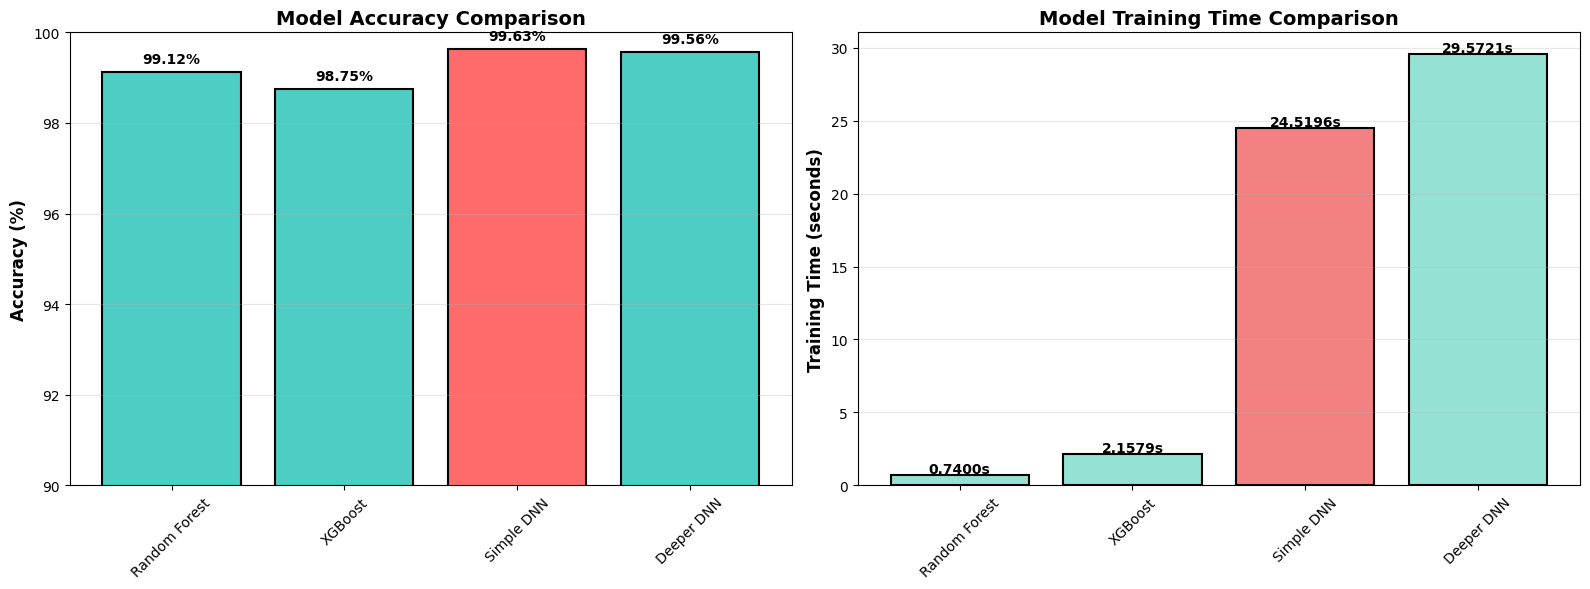

✓ Comparison visualization complete!


In [45]:
# Visualize model comparison
print("\nGenerating comparison visualizations...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Accuracy Comparison
model_names = list(model_performance.keys())
accuracies = [model_performance[name]*100 for name in model_names]
colors = ['#FF6B6B' if name == best_model_name else '#4ECDC4' for name in model_names]

axes[0].bar(model_names, accuracies, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
axes[0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylim([90, 100])  # Focus on upper range
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (name, acc) in enumerate(zip(model_names, accuracies)):
    axes[0].text(i, acc + 0.2, f'{acc:.2f}%', ha='center', fontweight='bold')

axes[0].tick_params(axis='x', rotation=45)

# Chart 2: Training Time Comparison
training_times = {
    'Random Forest': rf_training_time,
    'XGBoost': xgb_training_time,
    'Simple DNN': simple_training_time,
    'Deeper DNN': deeper_training_time
}

time_names = list(training_times.keys())
times = list(training_times.values())
colors_time = ['#95E1D3', '#95E1D3', '#F38181', '#95E1D3']

axes[1].bar(time_names, times, color=colors_time, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('Training Time (seconds)', fontsize=12, fontweight='bold')
axes[1].set_title('Model Training Time Comparison', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Add value labels
for i, (name, t) in enumerate(zip(time_names, times)):
    axes[1].text(i, t + 0.01 if t < 0.5 else t + 0.1, f'{t:.4f}s', ha='center', fontweight='bold')

axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("✓ Comparison visualization complete!")

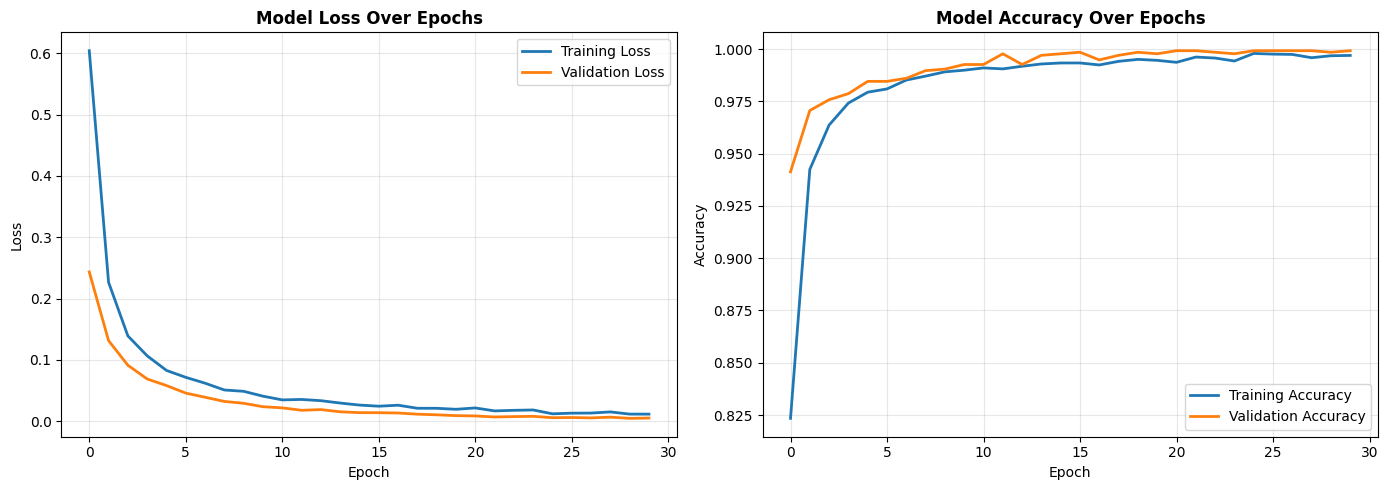

✓ Training metrics plotted


In [33]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(simple_history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(simple_history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Model Loss Over Epochs', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(simple_history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(simple_history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_title('Model Accuracy Over Epochs', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Training metrics plotted")

In [34]:
# Save the model and scaler for later use
import pickle

model_save_path = 'models/hand_gesture_model.h5'
scaler_save_path = 'models/scaler.pkl'
label_encoder_path = 'models/label_encoder.pkl'

simple_dnn.save(model_save_path)
print(f"Model saved to: {model_save_path}")

# Save the fitted scaler
with open(scaler_save_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"Scaler saved to: {scaler_save_path}")

# Save the label encoder
with open(label_encoder_path, 'wb') as f:
    pickle.dump(label_encoder, f)
print(f"Label encoder saved to: {label_encoder_path}")

Model saved to: models/hand_gesture_model.h5
Scaler saved to: models/scaler.pkl
Label encoder saved to: models/label_encoder.pkl


In [37]:
# Confusion Matrix
cm = confusion_matrix(y_test, simple_pred)

print("\nConfusion Matrix:")
print(cm)

# Classification Report
print("\n" + "="*60)
print("Classification Report:")
print("="*60)
print(classification_report(
    y_test, simple_pred,
    target_names=label_encoder.classes_,
    digits=2
))


Confusion Matrix:
[[193   0   0   2   0   0   0]
 [  0 194   0   0   0   0   0]
 [  0   0 193   0   1   1   0]
 [  0   0   0 195   0   0   0]
 [  0   0   0   1 194   0   0]
 [  0   0   0   0   0 195   0]
 [  0   0   0   0   0   0 195]]

Classification Report:
              precision    recall  f1-score   support

        fist       1.00      0.99      0.99       195
index_finger       1.00      1.00      1.00       194
          ok       1.00      0.99      0.99       195
   open_palm       0.98      1.00      0.99       195
       peace       0.99      0.99      0.99       195
    thumb_up       0.99      1.00      1.00       195
unrecognized       1.00      1.00      1.00       195

    accuracy                           1.00      1364
   macro avg       1.00      1.00      1.00      1364
weighted avg       1.00      1.00      1.00      1364



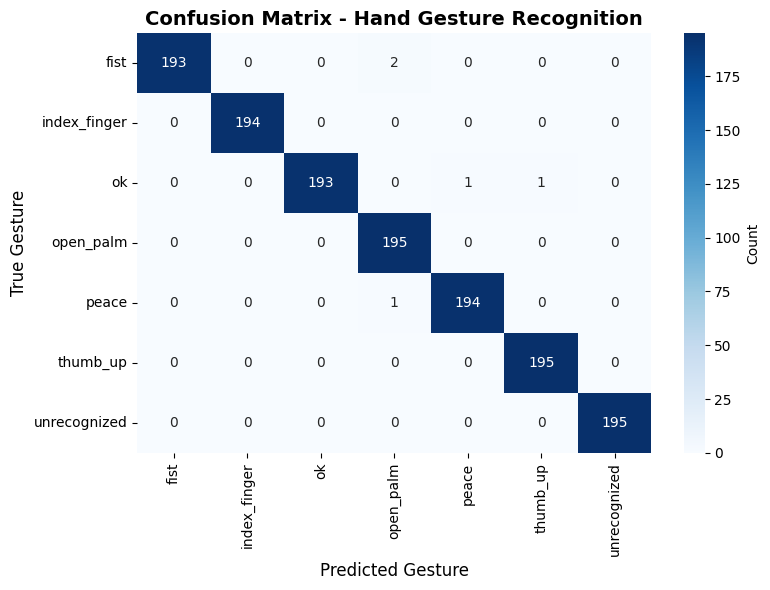

In [38]:
# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cbar_kws={'label': 'Count'})

plt.title('Confusion Matrix - Hand Gesture Recognition', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Gesture', fontsize=12)
plt.ylabel('True Gesture', fontsize=12)
plt.tight_layout()
plt.show()